Saving 0000.csv to 0000 (1).csv
Dataset shape: (32399, 12)


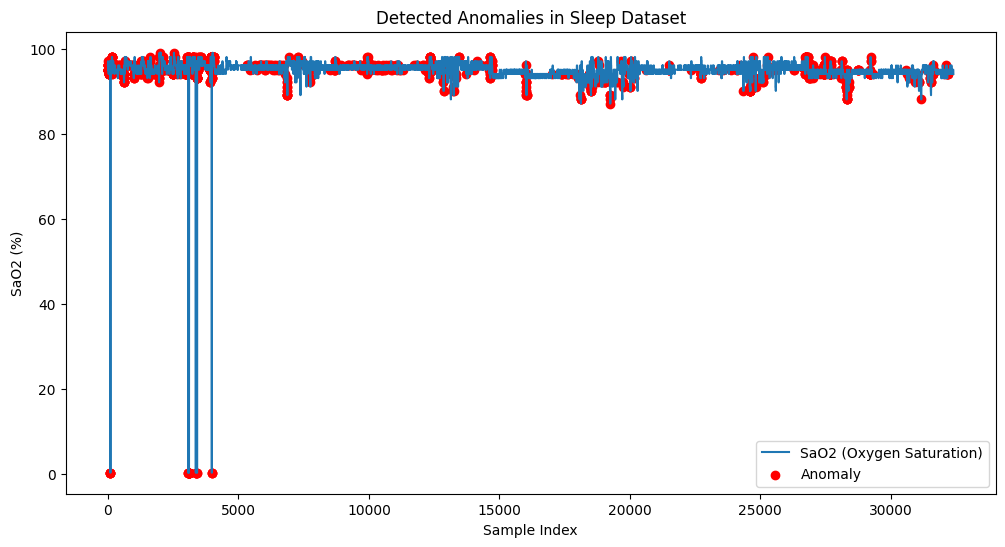

Total anomalies detected: 1620
Percentage anomalies: 5.0001543257507945


,SaO2,PR,EEG(sec),ECG,anomaly
0,96.011160,67.264629,0.980392,-0.266667,1
1,96.011160,67.264629,3.921569,-0.211765,1
2,96.011160,69.262709,2.941176,-0.250980,1
3,96.011160,72.259828,-0.000000,-0.203922,1
4,97.010197,78.241885,-7.843137,-0.227451,1
5,96.011160,80.239965,5.882353,-0.258824,1
6,96.011160,81.239004,-9.803922,-0.235294,1
7,96.011160,81.239004,1.960784,-0.219608,1
8,95.012122,80.239965,12.745098,-0.243137,1
9,95.012122,81.239004,-6.862745,-0.219608,1


In [ ]:
!pip install -q scikit-learn pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

from google.colab import files
uploaded = files.upload()

file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

print("Dataset shape:", df.shape)
df.head()

df = df.select_dtypes(include=[np.number])

df = df.fillna(df.mean())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

clf = IsolationForest(
    n_estimators=200,
    max_samples='auto',
    contamination=0.05, 
    random_state=42
)
clf.fit(X_scaled)


# Prediction:- 1 = normal, -1 = anomaly
y_pred = clf.predict(X_scaled)

# Convert predictions to binary (0 = normal, 1 = anomaly)
df['anomaly'] = np.where(y_pred == -1, 1, 0)

plt.figure(figsize=(12,6))
plt.title("Detected Anomalies in Sleep Dataset")
plt.plot(df.index, df['SaO2'], label="SaO2 (Oxygen Saturation)")
plt.scatter(df.index[df['anomaly']==1], df['SaO2'][df['anomaly']==1], color='red', label="Anomaly")
plt.xlabel("Sample Index")
plt.ylabel("SaO2 (%)")
plt.legend()
plt.show()

print("Total anomalies detected:", df['anomaly'].sum())
print("Percentage anomalies:", 100 * df['anomaly'].sum() / len(df))

df[['SaO2', 'PR', 'EEG(sec)', 'ECG', 'anomaly']].head(10)
